# Laboratorio Interactivo: Búsqueda Local (Hill Climbing)

Bienvenidos a esta sesión práctica. En este cuaderno exploraremos empíricamente el comportamiento de los algoritmos de búsqueda local, específicamente el **Hill Climbing (Escalada de Colina)**, aplicado a un entorno altamente no convexo: la **Función de Ackley**.

## 1. Definición del Problema

La función de Ackley es un *benchmark* clásico en la optimización. Se caracteriza por tener un **embudo global** (una tendencia general hacia el centro) pero está plagada de **múltiples óptimos locales** (crestas y valles) debido a su componente cosenoidal.

**Fórmula matemática:**


$$f(x, y) = -20 \cdot \exp\left(-0.2 \sqrt{0.5(x^2 + y^2)}\right) - \exp\left(0.5(\cos(2\pi x) + \cos(2\pi y))\right) + 20 + e$$

* **Dominio de evaluación:** $x, y \in [-5, 5]$.
* **Óptimo global:** Se ubica exactamente en el origen $(0, 0)$, donde $f(0,0) = 0$.
* **Problema para Hill Climbing:** Al ser un algoritmo avaro (*greedy*) que solo toma pasos descendentes (minimizando), quedará invariablemente atrapado en el primer valle local que encuentre si el tamaño de paso no es suficiente para "saltar" la cresta.

---

### [Celda de Código 1: Importación de Librerías]

In [1]:
# Importación de librerías fundamentales
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import ipywidgets as widgets
from IPython.display import display, clear_output
import time

# Configuración de visualización de matplotlib
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

---

### [Celda de Texto 2: Definición y Visualización Estática]

## 2. La Función de Ackley y su Paisaje de Energía (Energy Landscape)

Primero, definiremos matemáticamente la función y visualizaremos su topología en 2D (mapa de contornos) y 3D (superficie). Esto nos permitirá entender a qué se enfrenta nuestro algoritmo.

---

### [Celda de Código 2: Definición y Gráficas de la Función]

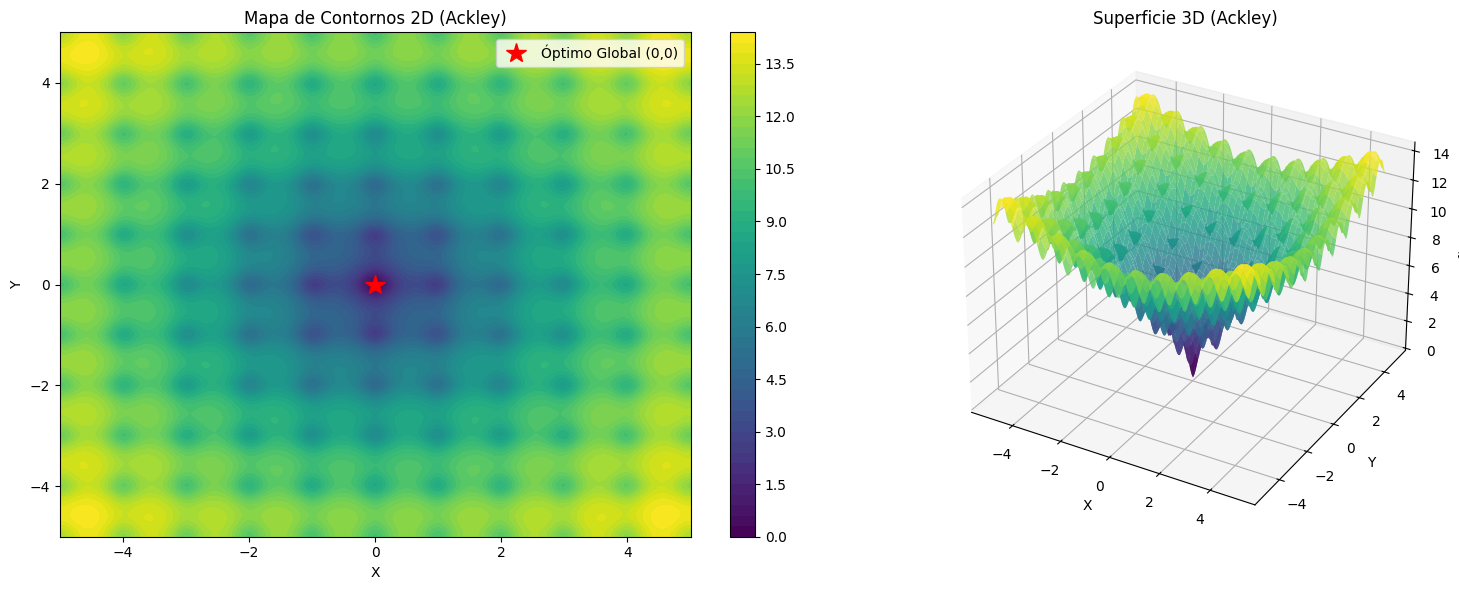

In [2]:
def ackley(x, y):
    """Implementación vectorizada de la función de Ackley 2D."""
    term1 = -20.0 * np.exp(-0.2 * np.sqrt(0.5 * (x**2 + y**2)))
    term2 = -np.exp(0.5 * (np.cos(2 * np.pi * x) + np.cos(2 * np.pi * y)))
    return term1 + term2 + 20.0 + np.e

# Crear la malla de puntos para graficar
x_range = np.linspace(-5, 5, 200)
y_range = np.linspace(-5, 5, 200)
X, Y = np.meshgrid(x_range, y_range)
Z = ackley(X, Y)

def plot_ackley_static():
    """Genera la visualización 2D Contour y 3D Surface de la función."""
    fig = plt.figure(figsize=(16, 6))

    # Gráfica 2D Contour
    ax1 = fig.add_subplot(121)
    contour = ax1.contourf(X, Y, Z, levels=50, cmap='viridis')
    fig.colorbar(contour, ax=ax1)
    ax1.plot(0, 0, 'r*', markersize=15, label='Óptimo Global (0,0)')
    ax1.set_title('Mapa de Contornos 2D (Ackley)')
    ax1.set_xlabel('X')
    ax1.set_ylabel('Y')
    ax1.legend()

    # Gráfica 3D Surface
    ax2 = fig.add_subplot(122, projection='3d')
    surf = ax2.plot_surface(X, Y, Z, cmap='viridis', alpha=0.8, edgecolor='none')
    ax2.set_title('Superficie 3D (Ackley)')
    ax2.set_xlabel('X')
    ax2.set_ylabel('Y')
    ax2.set_zlabel('f(x,y)')

    plt.tight_layout()
    plt.show()

plot_ackley_static()

---

### [Celda de Texto 3: Algoritmo Hill Climbing]

## 3. Implementación del Motor Lógico: Hill Climbing

El algoritmo evaluará vecinos alrededor del estado actual $(x, y)$. Si encuentra un vecino estrictamente mejor (menor valor de función), se moverá allí. Si ningún vecino mejora el estado actual, asumimos que hemos convergido (atrapados en un óptimo local o en el global).

---

### [Celda de Código 3: Clase del Motor Interactivo]

In [3]:
class HillClimbingAckley:
    def __init__(self):
        self.bounds = [-5.0, 5.0]
        self.reset_state(x_init=4.0, y_init=4.0, step_size=0.1)

    def reset_state(self, x_init, y_init, step_size):
        """Reinicia el estado del algoritmo."""
        self.x = np.clip(x_init, self.bounds[0], self.bounds[1])
        self.y = np.clip(y_init, self.bounds[0], self.bounds[1])
        self.step_size = step_size
        self.f_val = ackley(self.x, self.y)
        self.history = [(self.x, self.y, self.f_val)]
        self.stuck = False
        self.log = [f"Inicio en ({self.x:.2f}, {self.y:.2f}) | f = {self.f_val:.4f}"]

    def generate_neighbors(self, num_neighbors=8):
        """Genera vecinos en un radio igual a step_size."""
        angles = np.linspace(0, 2*np.pi, num_neighbors, endpoint=False)
        neighbors = []
        for ang in angles:
            nx = self.x + self.step_size * np.cos(ang)
            ny = self.y + self.step_size * np.sin(ang)
            # Mantener dentro de los límites
            nx = np.clip(nx, self.bounds[0], self.bounds[1])
            ny = np.clip(ny, self.bounds[0], self.bounds[1])
            neighbors.append((nx, ny))
        return neighbors

    def step(self):
        """Ejecuta una iteración lógica del Hill Climbing."""
        if self.stuck:
            return False

        neighbors = self.generate_neighbors()
        best_nx, best_ny = self.x, self.y
        best_nf = self.f_val

        # Evaluar vecinos
        for nx, ny in neighbors:
            nf = ackley(nx, ny)
            if nf < best_nf:
                best_nf = nf
                best_nx = nx
                best_ny = ny

        # Criterio de mejora estricta
        if best_nf < self.f_val:
            self.log.append(f"Mejora: Mueve a ({best_nx:.2f}, {best_ny:.2f}) | f = {best_nf:.4f}")
            self.x, self.y = best_nx, best_ny
            self.f_val = best_nf
            self.history.append((self.x, self.y, self.f_val))
            return True
        else:
            self.log.append(f"Atrapado en óptimo local. f_min = {self.f_val:.4f}")
            self.stuck = True
            return False

---

### [Celda de Texto 4: Entorno de Visualización Interactiva]

## 4. Visualización Interactiva y Panel de Control

A continuación, utilizamos `ipywidgets` para crear un panel de control completo.
**Instrucciones para el estudiante:**

1. Modifica la posición inicial (X, Y) y observa cómo el algoritmo cae en diferentes cuencas de atracción.
2. Modifica el *Step Size* (tamaño de paso). ¿Qué ocurre si el paso es muy grande? ¿Logra escapar de mínimos locales o salta caóticamente?
3. Utiliza "Paso a Paso" para leer el log de decisiones lógicas en tiempo real.

---

### [Celda de Código 4: Interfaz Gráfica (GUI) con Ipywidgets]

In [4]:
def create_interactive_gui():
    engine = HillClimbingAckley()

    # Widgets de entrada
    w_x_init = widgets.FloatSlider(value=3.5, min=-5.0, max=5.0, step=0.1, description='X Inicial:')
    w_y_init = widgets.FloatSlider(value=-3.5, min=-5.0, max=5.0, step=0.1, description='Y Inicial:')
    w_step = widgets.FloatSlider(value=0.15, min=0.01, max=1.0, step=0.05, description='Step Size:')

    # Botones
    btn_step = widgets.Button(description='Paso a Paso', button_style='info', icon='step-forward')
    btn_run = widgets.Button(description='Animación Auto', button_style='success', icon='play')
    btn_reset = widgets.Button(description='Reiniciar', button_style='danger', icon='refresh')

    out_plot = widgets.Output()
    out_log = widgets.Output()

    def update_visuals():
        with out_plot:
            clear_output(wait=True)
            fig = plt.figure(figsize=(14, 5))

            # Trayectoria 2D
            ax1 = fig.add_subplot(121)
            contour = ax1.contourf(X, Y, Z, levels=40, cmap='viridis')
            ax1.plot(0, 0, 'r*', markersize=15, label='Óptimo Global')

            hx = [p[0] for p in engine.history]
            hy = [p[1] for p in engine.history]
            ax1.plot(hx, hy, 'w.-', linewidth=2, markersize=8, label='Trayectoria HC')
            ax1.plot(hx[-1], hy[-1], 'ro', markersize=10, label='Estado Actual')

            ax1.set_xlim(-5, 5); ax1.set_ylim(-5, 5)
            ax1.set_title("Trayectoria en Espacio 2D")
            ax1.legend()

            # Curva de Convergencia
            ax2 = fig.add_subplot(122)
            hf = [p[2] for p in engine.history]
            ax2.plot(range(len(hf)), hf, 'b-', marker='o', linewidth=2)
            ax2.axhline(y=0, color='r', linestyle='--', label='Óptimo Global (0)')
            ax2.set_title("Curva de Convergencia")
            ax2.set_xlabel("Iteraciones")
            ax2.set_ylabel("Valor de f(x,y)")
            ax2.grid(True)
            ax2.legend()

            plt.tight_layout()
            plt.show()

        with out_log:
            clear_output(wait=True)
            print("--- LOG DE DECISIONES ---")
            for line in engine.log[-10:]: # Mostrar últimos 10 pasos
                print(line)

    def on_reset(b):
        engine.reset_state(w_x_init.value, w_y_init.value, w_step.value)
        update_visuals()

    def on_step(b):
        engine.step()
        update_visuals()

    def on_run(b):
        btn_run.disabled = True
        btn_step.disabled = True
        while not engine.stuck and len(engine.history) < 100: # Max 100 iter por seguridad
            engine.step()
            update_visuals()
            time.sleep(0.1) # Pausa para animación
        btn_run.disabled = False
        btn_step.disabled = False

    # Asignar eventos
    btn_reset.on_click(on_reset)
    btn_step.on_click(on_step)
    btn_run.on_click(on_run)
    w_x_init.observe(lambda c: on_reset(None), names='value')
    w_y_init.observe(lambda c: on_reset(None), names='value')
    w_step.observe(lambda c: on_reset(None), names='value')

    # Desplegar interfaz
    controls = widgets.VBox([
        widgets.HBox([w_x_init, w_y_init, w_step]),
        widgets.HBox([btn_step, btn_run, btn_reset])
    ])

    display(controls, out_plot, out_log)
    on_reset(None) # Inicializar vista

# Ejecutar la aplicación
create_interactive_gui()

Output()

Output()

---

### [Celda de Texto 5: Análisis y Errores Comunes]

## 5. Explicación Didáctica y Errores Comunes

**Análisis Visual del Fallo (Miopía Algorítmica):**
Al ejecutar la celda interactiva, notarás que la trayectoria blanca rara vez llega a la estrella roja $(0,0)$. El algoritmo se desliza rápidamente hacia el centro (explotando la pendiente convexa de la función exponencial), pero de repente se detiene. Esto ocurre porque cae en uno de los profundos "agujeros" generados por la oscilación del coseno. Al evaluar el vecindario inmediato (controlado por `step_size`), todos los pasos implican subir la pared del agujero, y dado que Hill Climbing rechaza soluciones temporalmente peores ($\Delta f > 0$), se rinde prematuramente.

**Errores Comunes en la Implementación:**

1. **Tamaño de paso excesivo:** Si colocan el `step_size` en $1.0$, el algoritmo podría "saltar" los óptimos locales, pero también oscilará alrededor del óptimo global sin poder converger al fondo exacto del valle (es como tratar de embocar una canica en un hoyo pequeño con pasos de gigante).
2. **No restringir el vecindario (Bounds):** Es vital usar la función `np.clip` al generar vecinos. De lo contrario, el algoritmo podría explotar hacia el infinito si la función objetivo estuviera mal formulada en los bordes.

---